# Scratch: long-read PCs (population + HG/NA + ancestry gaps)

1. Plot global `lr_PC*` colored by continental `population` from
   `tractor_mix/covariates.source_rebuilt.csv.gz`. HG/NA controls are drawn
   on top with the same colors but higher opacity.
2. Find joint-callset samples missing both ancestry labels and `population`, then
   infer continental codes from `lr_PC` space (nearest centroid + kNN).
3. Per-population 2D / 3D panels: global vs within-pop long-read PCs.

**Mainline ancestry fills:** `tractor_05a_fill_lr_ancestry.ipynb`.

**Mahalanobis local-PC outlier QC (separate, does not write covariates):**
`explore_lr_pop_mahalanobis_qc.ipynb`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("..").resolve()
PCS_PATH = ROOT / "tractor_mix" / "pca" / "deepvariant_lr_v1" / "global_pcs.tsv"
COV_PATH = ROOT / "tractor_mix" / "covariates.source_rebuilt.csv.gz"

POP_ORDER = ["AFR", "AMR", "EAS", "EUR", "SAS", "MID", "OTH", "missing"]
POP_COLORS = {
    "AFR": "#e41a1c",
    "AMR": "#ff7f00",
    "EAS": "#4daf4a",
    "EUR": "#377eb8",
    "SAS": "#984ea3",
    "MID": "#a65628",
    "OTH": "#999999",
    "missing": "#cccccc",
}

pcs = pd.read_csv(PCS_PATH, sep="\t", dtype={"research_id": str})
cov = pd.read_csv(COV_PATH, dtype={"research_id": str}, usecols=["research_id", "population"])

df = pcs.merge(cov, on="research_id", how="left")
df["is_hg_na"] = df["research_id"].str.startswith(("HG", "NA"))
df["population"] = df["population"].fillna("missing").astype(str)

print(f"samples: {len(df):,}")
print(f"HG/NA:   {df['is_hg_na'].sum():,}")
print(f"missing population after join: {(df['population'] == 'missing').sum():,}")
display(df["population"].value_counts())
df.head()

samples: 12,553
HG/NA:   292
missing population after join: 0


population
OTH    2748
AFR    2744
AMR    2131
EUR    1901
EAS    1372
SAS    1241
MID     416
Name: count, dtype: int64

,research_id,lr_PC1,lr_PC2,lr_PC3,lr_PC4,lr_PC5,lr_PC6,lr_PC7,lr_PC8,lr_PC9,...,lr_PC25,lr_PC26,lr_PC27,lr_PC28,lr_PC29,lr_PC30,lr_PC31,lr_PC32,population,is_hg_na
0,1000234,0.119460,-0.129260,0.042160,-0.034507,-0.095620,0.012609,-0.059876,-0.005533,-0.002143,...,0.002684,0.000196,0.000395,-0.000298,-0.000179,-0.000973,0.001140,-0.001417,OTH,False
1,1000291,0.092199,-0.089680,-0.030500,-0.034953,0.007476,-0.010195,0.028870,-0.040895,-0.027372,...,-0.004580,-0.011141,0.004177,0.001751,-0.005846,0.011070,0.004032,0.004324,AMR,False
2,1000610,0.128460,-0.133070,0.016685,-0.044874,0.054441,0.002982,-0.002038,0.003282,0.000346,...,0.002549,-0.001985,0.000474,-0.002648,0.000867,-0.003577,0.003237,-0.001822,EUR,False
3,1000612,-0.346580,0.029471,0.004448,0.004911,-0.002661,0.003272,-0.008645,0.006471,0.008180,...,0.012508,-0.004834,-0.012656,0.016121,-0.005313,0.008312,0.015548,-0.000218,AFR,False
4,1000753,0.119210,-0.131210,0.042269,-0.031765,-0.091090,0.014459,-0.056685,-0.003042,-0.000047,...,-0.001303,0.001782,-0.001640,-0.001760,0.000919,-0.000066,-0.000899,-0.003714,EUR,False


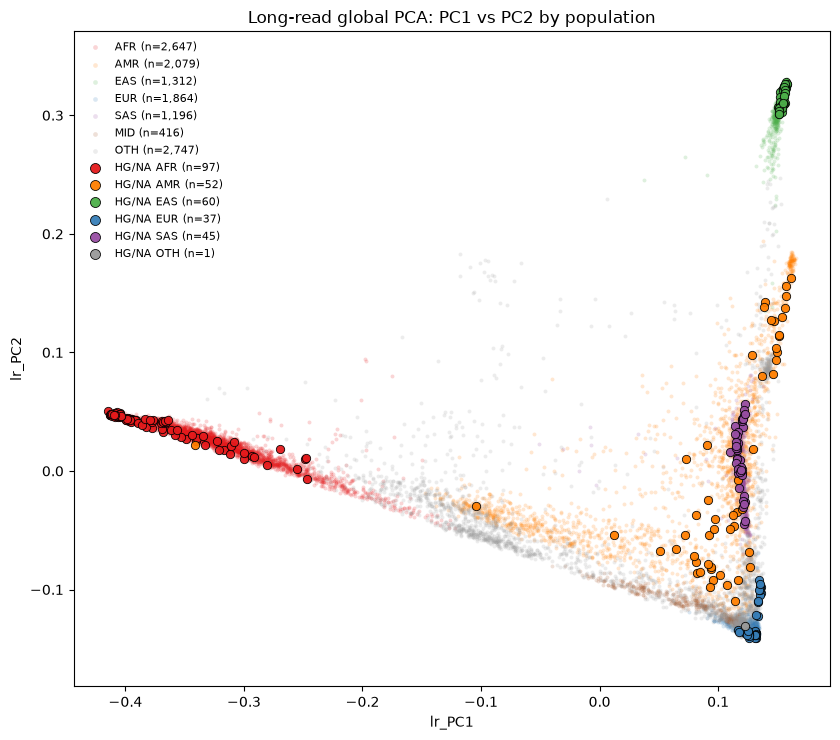

In [2]:
other = df.loc[~df["is_hg_na"]]
hg_na = df.loc[df["is_hg_na"]]

fig, ax = plt.subplots(figsize=(8.5, 7.5))

for pop in POP_ORDER:
    sub = other.loc[other["population"] == pop]
    if sub.empty:
        continue
    ax.scatter(
        sub["lr_PC1"],
        sub["lr_PC2"],
        s=8,
        alpha=0.18,
        c=POP_COLORS[pop],
        linewidths=0,
        label=f"{pop} (n={len(sub):,})",
        zorder=1,
    )

for pop in POP_ORDER:
    sub = hg_na.loc[hg_na["population"] == pop]
    if sub.empty:
        continue
    ax.scatter(
        sub["lr_PC1"],
        sub["lr_PC2"],
        s=36,
        alpha=0.95,
        c=POP_COLORS[pop],
        edgecolors="black",
        linewidths=0.6,
        label=f"HG/NA {pop} (n={len(sub):,})",
        zorder=2,
    )

ax.set_xlabel("lr_PC1")
ax.set_ylabel("lr_PC2")
ax.set_title("Long-read global PCA: PC1 vs PC2 by population")
ax.legend(frameon=False, loc="best", fontsize=8, markerscale=1.2)
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plt.show()

## Ancestry gaps in the joint callset

Focus on samples with `has_lr_pcs` that still lack both `ancestry_pred` /
`ancestry_pred_other` **and** continental `population`. These typically have no
short-read WGS / short-read PCs, so labels have to come from long-read PC space.

After the rebuilt covariates + fill notebook, this set may already be empty.


In [3]:
from collections import Counter

import numpy as np

cov_full = pd.read_csv(
    COV_PATH,
    dtype={"research_id": str},
    low_memory=False,
)

def is_missing(s: pd.Series) -> pd.Series:
    return s.isna() | (s.astype(str).str.strip() == "") | (s.astype(str).str.upper() == "NA")

miss_anc = is_missing(cov_full["ancestry_pred"]) | is_missing(cov_full["ancestry_pred_other"])
miss_pop = is_missing(cov_full["population"])
in_pcs = cov_full["has_lr_pcs"] == True

print("Joint-callset (has_lr_pcs) ancestry gaps:")
print(f"  missing ancestry_pred / ancestry_pred_other: {(in_pcs & miss_anc).sum()}")
print(f"  missing population:                         {(in_pcs & miss_pop).sum()}")
print(f"  missing BOTH:                               {(in_pcs & miss_anc & miss_pop).sum()}")

gap = cov_full.loc[in_pcs & miss_anc & miss_pop].copy()
display(
    gap[
        [
            "research_id",
            "lr_phase",
            "has_srWGS",
            "has_global_pcs",
            "final_releasable_v9",
            "has_PacBio",
            "has_ONT",
            "sex_at_birth",
            "lr_PC1",
            "lr_PC2",
        ]
    ]
)
print("All gap samples have lr_PCs; none have short-read PCs / srWGS.")


Joint-callset (has_lr_pcs) ancestry gaps:
  missing ancestry_pred / ancestry_pred_other: 0
  missing population:                         0
  missing BOTH:                               0


,research_id,lr_phase,has_srWGS,has_global_pcs,final_releasable_v9,has_PacBio,has_ONT,sex_at_birth,lr_PC1,lr_PC2


All gap samples have lr_PCs; none have short-read PCs / srWGS.


## Infer continental labels from `lr_PC1`–`lr_PC10`

Train on joint-callset samples that already have `ancestry_pred_other`. For each
gap sample (if any remain):

- **nearest centroid** in standardized PC space
- **kNN (k=15)** majority vote

High confidence = methods agree and (kNN fraction ≥ 0.8 **or** centroid margin ≥ 0.5).


In [4]:
LR_PC_COLS = [f"lr_PC{i}" for i in range(1, 11)]
K = 15
INFERRED_COLS = [
    "research_id",
    "centroid",
    "centroid_d",
    "centroid_margin",
    "knn15",
    "knn15_frac",
    "knn15_counts",
    "agree",
    "high_confidence",
    "suggested",
    "lr_PC1",
    "lr_PC2",
]

ref = cov_full.loc[in_pcs & ~miss_anc].copy()
ref["label"] = ref["ancestry_pred_other"].astype(str).str.lower()

print(f"Reference labeled samples: {len(ref):,}")
print(f"Label counts: {dict(Counter(ref['label']))}")
print(f"Gap samples to infer: {len(gap):,}")

if gap.empty:
    inferred = pd.DataFrame(columns=INFERRED_COLS)
    print("No ancestry+population gaps remain — nothing to infer.")
else:
    X_ref = ref[LR_PC_COLS].to_numpy(dtype=float)
    y_ref = ref["label"].to_numpy()
    X_gap = gap[LR_PC_COLS].to_numpy(dtype=float)

    mu = X_ref.mean(axis=0)
    sd = X_ref.std(axis=0)
    sd[sd == 0] = 1.0
    X_ref_z = (X_ref - mu) / sd
    X_gap_z = (X_gap - mu) / sd

    centroids = {
        lab: X_ref_z[y_ref == lab].mean(axis=0) for lab in sorted(set(y_ref))
    }

    def nearest_centroid(x: np.ndarray):
        dists = {lab: float(np.linalg.norm(x - c)) for lab, c in centroids.items()}
        ordered = sorted(dists.items(), key=lambda kv: kv[1])
        best, d1 = ordered[0]
        margin = ordered[1][1] - d1
        return best, d1, margin, ordered[:3]

    def knn_vote(x: np.ndarray, k: int = K):
        d = np.linalg.norm(X_ref_z - x, axis=1)
        idx = np.argpartition(d, k)[:k]
        counts = Counter(y_ref[idx])
        top, n_top = counts.most_common(1)[0]
        return top, n_top / k, dict(counts)

    rows = []
    for i, rid in enumerate(gap["research_id"].astype(str)):
        lab_c, d1, margin, top3 = nearest_centroid(X_gap_z[i])
        lab_k, frac, counts = knn_vote(X_gap_z[i])
        agree = lab_c == lab_k
        high_conf = bool(agree and (frac >= 0.8 or margin >= 0.5))
        rows.append(
            {
                "research_id": rid,
                "centroid": lab_c,
                "centroid_d": d1,
                "centroid_margin": margin,
                "knn15": lab_k,
                "knn15_frac": frac,
                "knn15_counts": counts,
                "agree": agree,
                "high_confidence": high_conf,
                "suggested": lab_k if high_conf else pd.NA,
                "lr_PC1": float(gap.iloc[i]["lr_PC1"]),
                "lr_PC2": float(gap.iloc[i]["lr_PC2"]),
            }
        )

    inferred = pd.DataFrame(rows, columns=INFERRED_COLS)
    print(f"Centroid vs kNN agree: {inferred['agree'].sum()}/{len(inferred)}")
    print(f"High confidence:       {inferred['high_confidence'].sum()}/{len(inferred)}")
    display(inferred.drop(columns=["lr_PC1", "lr_PC2"]))

    print("\nHigh-confidence suggested fills:")
    display(
        inferred.loc[
            inferred["high_confidence"],
            ["research_id", "suggested", "knn15_frac", "centroid_margin"],
        ]
    )
    print("\nLower-confidence (leave missing or review):")
    display(
        inferred.loc[
            ~inferred["high_confidence"],
            ["research_id", "centroid", "knn15", "knn15_frac", "centroid_margin", "knn15_counts"],
        ]
    )


Reference labeled samples: 12,553
Label counts: {'eur': 2214, 'amr': 2018, 'afr': 2913, 'oth': 2420, 'eas': 1369, 'sas': 1242, 'mid': 377}


KeyError: 'agree'

## PC1 vs PC2 with gap samples highlighted

Background: labeled joint-callset samples by `ancestry_pred_other`. Overlay: any
remaining gap samples, colored by **suggested** label when high-confidence,
otherwise black. Skips the overlay when `inferred` is empty.


In [ ]:
ANC_ORDER = ["afr", "amr", "eas", "eur", "sas", "mid", "oth"]
ANC_COLORS = {
    "afr": POP_COLORS["AFR"],
    "amr": POP_COLORS["AMR"],
    "eas": POP_COLORS["EAS"],
    "eur": POP_COLORS["EUR"],
    "sas": POP_COLORS["SAS"],
    "mid": POP_COLORS["MID"],
    "oth": POP_COLORS["OTH"],
}

fig, ax = plt.subplots(figsize=(8.5, 7.5))

for lab in ANC_ORDER:
    sub = ref.loc[ref["label"] == lab]
    if sub.empty:
        continue
    ax.scatter(
        sub["lr_PC1"],
        sub["lr_PC2"],
        s=6,
        alpha=0.12,
        c=ANC_COLORS[lab],
        linewidths=0,
        label=f"{lab} ref (n={len(sub):,})",
        zorder=1,
    )

n_gap = len(inferred)
for _, row in inferred.iterrows():
    if row["high_confidence"]:
        color = ANC_COLORS[row["suggested"]]
        edge = "black"
    else:
        color = "black"
        edge = "yellow"
    ax.scatter(
        row["lr_PC1"],
        row["lr_PC2"],
        s=70,
        alpha=0.95,
        c=color,
        edgecolors=edge,
        linewidths=0.8,
        zorder=3,
    )

if n_gap:
    ax.scatter([], [], s=70, c="gray", edgecolors="black", label="gap high-conf (colored)")
    ax.scatter([], [], s=70, c="black", edgecolors="yellow", label="gap low-conf")

ax.set_xlabel("lr_PC1")
ax.set_ylabel("lr_PC2")
ax.set_title(f"{n_gap} ancestry-gap sample(s) over labeled lr_PC space")
ax.legend(frameon=False, loc="best", fontsize=8, markerscale=1.2)
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plt.show()


## Per-population: global vs local long-read PCs

Two-panel plots for each continental `population` among joint-callset samples
(`has_lr_pcs`). Left: global `lr_PC1`–`lr_PC2` with that population highlighted.
Right: within-population `lr_pop_PC1`–`lr_pop_PC2` for the same samples.

In [ ]:
usecols = [
    "research_id",
    "population",
    "has_lr_pcs",
    "has_lr_pop_pcs",
    "lr_PC1",
    "lr_PC2",
    "lr_PC3",
    "lr_pop_PC1",
    "lr_pop_PC2",
    "lr_pop_PC3",
]
cov_pcs = pd.read_csv(COV_PATH, dtype={"research_id": str}, usecols=usecols)
cov_pcs = cov_pcs.loc[cov_pcs["has_lr_pcs"] == True].copy()
cov_pcs["is_hg_na"] = cov_pcs["research_id"].str.startswith(("HG", "NA"))
cov_pcs["population"] = cov_pcs["population"].fillna("missing").astype(str)

POP_FOCUS = [p for p in POP_ORDER if p != "missing" and (cov_pcs["population"] == p).any()]

print(f"joint-callset samples: {len(cov_pcs):,}")
print(f"with lr_pop_PCs:       {cov_pcs['has_lr_pop_pcs'].sum():,}")
display(cov_pcs["population"].value_counts().reindex(POP_FOCUS))


In [ ]:
def plot_population_panels(pop: str, data: pd.DataFrame) -> None:
    focus = data.loc[data["population"] == pop]
    background = data.loc[data["population"] != pop]
    n_focus = len(focus)
    n_local = focus["lr_pop_PC1"].notna().sum()
    n_ctrl = int(focus["is_hg_na"].sum())
    color = POP_COLORS.get(pop, "#333333")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

    ax = axes[0]
    ax.scatter(
        background["lr_PC1"],
        background["lr_PC2"],
        s=6,
        alpha=0.12,
        c="#bbbbbb",
        linewidths=0,
        zorder=1,
    )
    ax.scatter(
        focus["lr_PC1"],
        focus["lr_PC2"],
        s=14,
        alpha=0.55,
        c=color,
        linewidths=0,
        zorder=2,
    )
    ax.set_xlabel("lr_PC1")
    ax.set_ylabel("lr_PC2")
    ax.set_title("Global long-read PCs")
    ax.set_aspect("equal", adjustable="datalim")

    ax = axes[1]
    local = focus.loc[focus["lr_pop_PC1"].notna() & focus["lr_pop_PC2"].notna()]
    ax.scatter(
        local["lr_pop_PC1"],
        local["lr_pop_PC2"],
        s=14,
        alpha=0.55,
        c=color,
        linewidths=0,
        zorder=1,
    )
    ax.set_xlabel("lr_pop_PC1")
    ax.set_ylabel("lr_pop_PC2")
    ax.set_title("Within-population long-read PCs")
    ax.set_aspect("equal", adjustable="datalim")

    fig.suptitle(
        f"{pop}: n={n_focus:,} highlighted  |  local PCs n={n_local:,}  |  HG/NA controls={n_ctrl}",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()


for pop in POP_FOCUS:
    plot_population_panels(pop, cov_pcs)


## Per-population: global vs local long-read PCs (3D)

Same layout as above, but using `lr_PC1`–`lr_PC3` (left) and
`lr_pop_PC1`–`lr_pop_PC3` (right). Rotate interactively in the notebook UI if
the backend supports it.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def plot_population_panels_3d(pop: str, data: pd.DataFrame) -> None:
    focus = data.loc[data["population"] == pop]
    background = data.loc[data["population"] != pop]
    n_focus = len(focus)
    n_local = (
        focus[["lr_pop_PC1", "lr_pop_PC2", "lr_pop_PC3"]].notna().all(axis=1).sum()
    )
    n_ctrl = int(focus["is_hg_na"].sum())
    color = POP_COLORS.get(pop, "#333333")

    fig = plt.figure(figsize=(13, 5.8))
    ax0 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1 = fig.add_subplot(1, 2, 2, projection="3d")

    ax0.scatter(
        background["lr_PC1"],
        background["lr_PC2"],
        background["lr_PC3"],
        s=4,
        alpha=0.06,
        c="#bbbbbb",
        linewidths=0,
        depthshade=False,
    )
    ax0.scatter(
        focus["lr_PC1"],
        focus["lr_PC2"],
        focus["lr_PC3"],
        s=10,
        alpha=0.55,
        c=color,
        linewidths=0,
        depthshade=False,
    )
    ax0.set_xlabel("lr_PC1")
    ax0.set_ylabel("lr_PC2")
    ax0.set_zlabel("lr_PC3")
    ax0.set_title("Global long-read PCs")
    ax0.view_init(elev=18, azim=-60)

    local = focus.loc[
        focus[["lr_pop_PC1", "lr_pop_PC2", "lr_pop_PC3"]].notna().all(axis=1)
    ]
    ax1.scatter(
        local["lr_pop_PC1"],
        local["lr_pop_PC2"],
        local["lr_pop_PC3"],
        s=10,
        alpha=0.55,
        c=color,
        linewidths=0,
        depthshade=False,
    )
    ax1.set_xlabel("lr_pop_PC1")
    ax1.set_ylabel("lr_pop_PC2")
    ax1.set_zlabel("lr_pop_PC3")
    ax1.set_title("Within-population long-read PCs")
    ax1.view_init(elev=18, azim=-60)

    fig.suptitle(
        f"{pop} (3D): n={n_focus:,} highlighted  |  local PCs n={n_local:,}  |  HG/NA controls={n_ctrl}",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()


for pop in POP_FOCUS:
    plot_population_panels_3d(pop, cov_pcs)
